# 01 — Exploratory Data Analysis

UCI Heart Disease (Cleveland) — 303 rows × 14 cols.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from src.data.preprocess import clean, load_raw
from src.config import TARGET, NUMERIC_FEATURES, CATEGORICAL_FEATURES
sns.set_theme(style='whitegrid')


## 1. Load + clean

In [2]:
df = clean(load_raw())
print(df.shape)
df.head()

2026-05-02 17:22:58,424 | INFO | Loaded raw frame: shape=(303, 14)


2026-05-02 17:22:58,508 | INFO | Imputing 6 missing values with column medians.


2026-05-02 17:22:58,529 | INFO | Cleaned frame: shape=(303, 14), target balance={0: 164, 1: 139}


(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Missing-value report

In [3]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## 3. Class balance

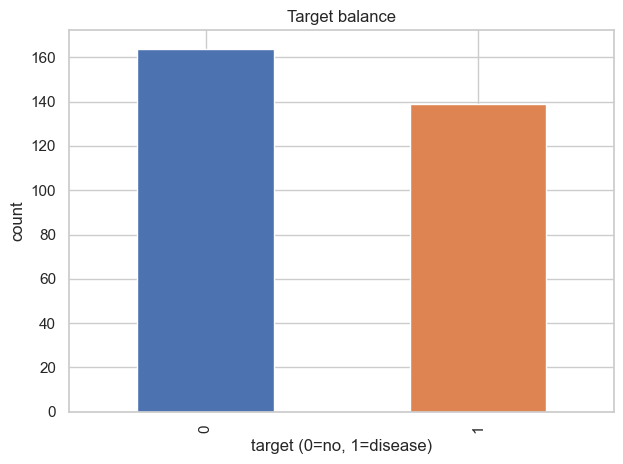

In [4]:
ax = df[TARGET].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'])
ax.set(title='Target balance', xlabel='target (0=no, 1=disease)', ylabel='count')
plt.tight_layout(); plt.savefig('../screenshots/01_eda_target_distribution.png', dpi=120)


## 4. Numeric distributions

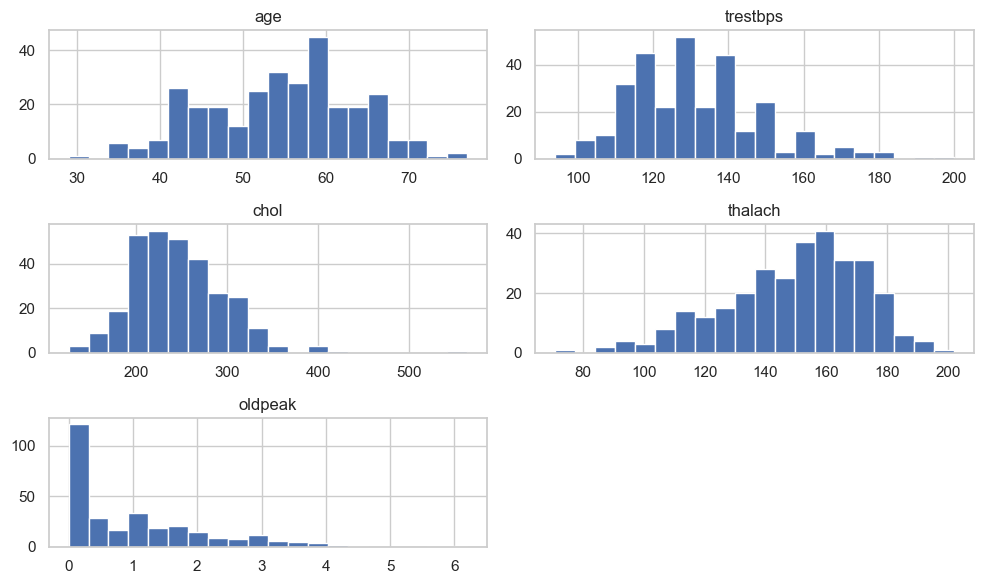

In [5]:
df[NUMERIC_FEATURES].hist(bins=20, figsize=(10, 6), color='#4C72B0')
plt.tight_layout()


## 5. Correlation heatmap

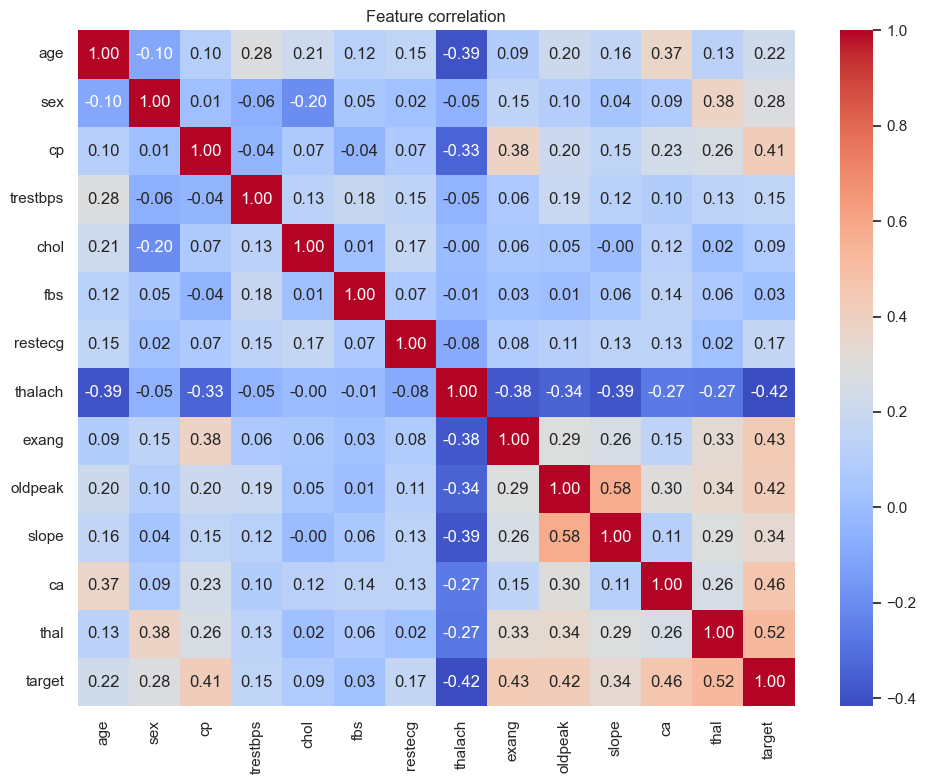

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Feature correlation')
plt.tight_layout(); plt.savefig('../screenshots/02_eda_correlation_heatmap.png', dpi=120)


## 6. Categorical vs target

2026-05-02 17:23:03,133 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-02 17:23:03,157 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-02 17:23:03,226 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-02 17:23:03,239 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-02 17:23:03,329 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-05-02 17:23:03,528 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-02 17:23:03,567 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-02 17:23:03,576 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-02 17:23:03,636 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-02 17:23:03,646 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


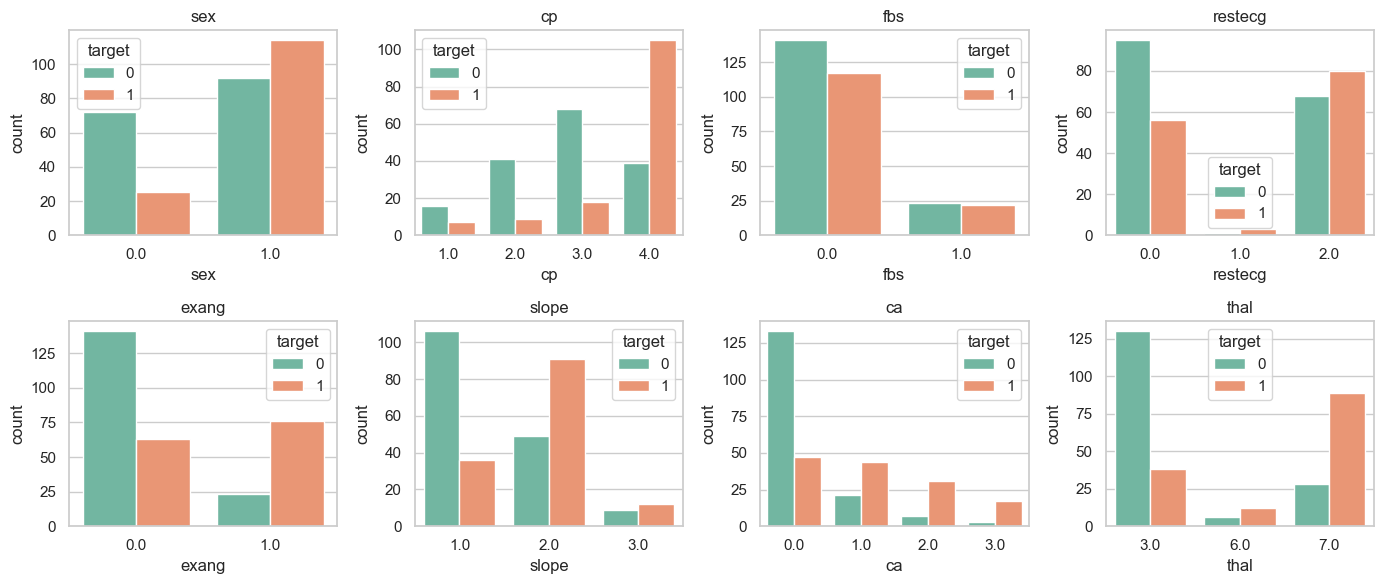

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, CATEGORICAL_FEATURES):
    sns.countplot(data=df, x=col, hue=TARGET, ax=ax, palette='Set2')
    ax.set_title(col)
plt.tight_layout()
